In [ ]:
### 2.1 Camera calibration and distortion correction
### 2.1 Hiệu chỉnh camera và hiệu chỉnh biến dạng
# pointExtraction: 

def pointExtraction(frame):
    # Xác định kích thước bàn cờ
    CHECKERBOARD = (6,9)
    #cretiria = ()

    # Tạo vector để lưu những vector 3D points cho mỗi checkerboard hình ảnh
    objpoints = []

    # Tạo vector để lưu những vector 2D points cho mỗi checkerboard hình ảnh
    imgpoints = []

    # Định nghĩa toạ độ cho các điểm 3D
    objp = np.zeros((1,CHECKERBOARD[0] * CHECKERBOARD[1],3),np.float32)
    objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

    images = glob.glob(frame)

    for idx, img in enumerate(images):
        image = cv2.imread(img)
        gray =cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
        # Tìm chess board corners
        # Nếu tìm thấy số lượng corners trong ảnh thì ret = true
        ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    
        if ret == True:
            objpoints.append(objp)
            imgpoints.append(corners)
    return objpoints, imgpoints

def cameraCalibrator(objpoints, imgpoints, image):
    imgRes = (image.shape[0], image.shape[1])
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera( objpoints, image, imgRes, None, None)
    undistorted = cv2.undistort(image, mtx, dist, None, mtx)

    return undistorted


## Advanced Lane Lines Detection using OpenCV

In [1]:
#import
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import re
import os
import pickle
import math

%matplotlib inline

In [2]:
### Utility Functions
def tryint(s):
    try:
        return int(s)
    except:
        return s
    

def alphanum_key(s):
    '''
    Turn a string into a list of string and number chunks.
    E.g. "z23a" -> ["z", 23, "a"]
    '''
    return [tryint(c) for c in re.split('([0-9]+)',s)]


def sort_nicely(l):
    '''
    Sort the given list in the way that humans expect.
    '''
    l.sort(key=alphanum_key)

def plot_imges(data, layout='row', cols=2, figsize=(20, 12)):
    '''
    Utility function for plotting images
    :param data [(ndarray, String)]: List of data to display, [(image, title)]
    :param layout (string): Layout. 'row',row-wise or column-wise
    :param cols (number): Number of columns per row
    :param figsize (number, number): Tuple indicating figure size
    '''

    rows =math.ceil(len(data) / cols)
    f, ax = plt.subplots(figsize=figsize)
    if layout == 'row':
        for idx, d in enumerate(data):
            img, title = d

            plt.subplot(rows, cols, idx + 1)
            plt.title(title, fontsize=20)
            plt.axis('off')
            if len(img.shape) == 2:
                plt.imshow(img, cmap='gray')
            elif len(img.shape) == 3:
                plt.imshow(img)
    elif layout == 'col':
        counter = 0
        for r in range(rows):
            for c in range(cols):
                img, title = data[r + rows*c]
                nb_channel = len(img.shape)

                plt.subplot(rows, cols, counter + 1)
                plt.title(title, fontsize=20)
                plt.axis('off')
                if len(img.shape) == 2:
                    plt.imshow(img, cmap='gray')
                elif len(img.shape) == 3:
                    plt.imshow(img)
                counter += 1
    return ax

def capture_frames(video_path, frames_dir):
    '''
   Utility function that captures and stores video frames
   :param video_path (string): Path to the video file
   :param frames_dir (string): Directory to store the captured frames
    '''
    cap = cv2.VideoCapture(video_path)

    print('Strarting frame capture')
    count = 0
    sussess = True
    while sussess:
        sussess, frame = cap.read()
        if sussess:
            cv2.imwrite(os.path.join(frames_dir, 'frame{:d}.jpg'.format(count)), frame)
            count += 1
    print('Finished frame capture. Total frames: {:d}'.format(count))

test_img_paths = glob.glob('./test_images/test*.jpg')
sort_nicely(test_img_paths)

video1 = glob.glob('./challenge_video.mp4')
sort_nicely(video1)

# List of all demos to visualize
plot_demo = [1,2,3,4,5,6,7,8]

### 1. Camera Calibration & Distortion Correction

In [3]:
##1 Camera Calibration & Distortion Correction

def calibrate_camera():
    '''
    Coptures the camera calibration matrix and distortion coefficients, and applies the undistortion transformation to the test images.
    :return: Camera calibration matrix and distortion coefficients
    '''
    imgpaths = glob.glob('./camera_cal/calibration*.jpg')
    sort_nicely(imgpaths)

    # View a sample calibration image
    %matplotlib inline
    image = cv2.imread(imgpaths[0])
    imshape = image.shape[:2] # Gets only the (height, width) of the image to be used in the cv2.calibrateCamera() function

    plt.imshow(image)
    plt.show()
    print('Image shape: {}'.format(imshape))

    # %matplotlib qt  # Removed to avoid warning; using %matplotlib inline from cell 0
    print()
    print('Calibrating the camera ...')
    print()
    
    objpoints = []
    imgpoints = []

    nx = 9 #  Number of inside corners on each row of the chessboard
    ny = 6 #  Number of inside corners on each column of the chessboard

    # Prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,5,0)
    objp = np.zeros((nx * ny, 3), np.float32)
    objp[:,:2] = np.mgrid[0:nx, 0:ny].T.reshape(-1, 2)

    # Iterate over each calibration image and determine the objpoints and imgpoints
    for idx, imgpath in enumerate(imgpaths):
        img = cv2.imread(imgpath)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Find the chessboard corners
        ret, corners = cv2.findChessboardCorners(gray, (nx, ny), None)

        # If found, add object points, image points
        if ret == True:
            img = cv2.drawChessboardCorners(img, (nx, ny), corners, ret)

            objpoints.append(objp)
            imgpoints.append(corners)

            # Draw and display the corners
            cv2.imshow('img', img)
            cv2.waitKey(500)
            cv2.destroyAllWindows()

    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, imshape[::-1], None, None)
    print('Camera calibration is complete.')
    return mtx, dist

# Note: the calibration process only needs to be run once in the absense of the pickled file
# containing the caculated aforementioned paremeters. If the pickled file is present, the parameters will be loaded from it instead of running the calibration process again.
if os.path.exists('camera_calib.p'):
    with open('camera_calib.p', 'rb') as f:
        dist_pickle = pickle.load(f)
        mtx = dist_pickle['mtx']
        dist = dist_pickle['dist']
        print('Loaded the saved camera calibration matrix and distortion coefficients from the pickled file.')
else:
    mtx, dist = calibrate_camera()
    dist_pickle = {'mtx': mtx, 'dist': dist}
    with open('camera_calib.p', 'wb') as f:
        pickle.dump(dist_pickle, f)
        print('Saved the camera calibration matrix and distortion coefficients to a pickled file for future use.')
              
# Undistort the test images and visualize the results
def undistort_images(img, mtx, dist):
    '''
    Undistorts the input image using the provided camera calibration matrix and distortion coefficients.
    :param img (ndarray): Input image to be undistorted
    :param mtx (ndarray): Camera calibration matrix
    :param dist (ndarray): Distortion coefficients
    :return: Undistorted image
    '''
    return cv2.undistort(img, mtx, dist, None, mtx)


Loaded the saved camera calibration matrix and distortion coefficients from the pickled file.


#### 1.1 Demonstration of camera calibration and distortion correction

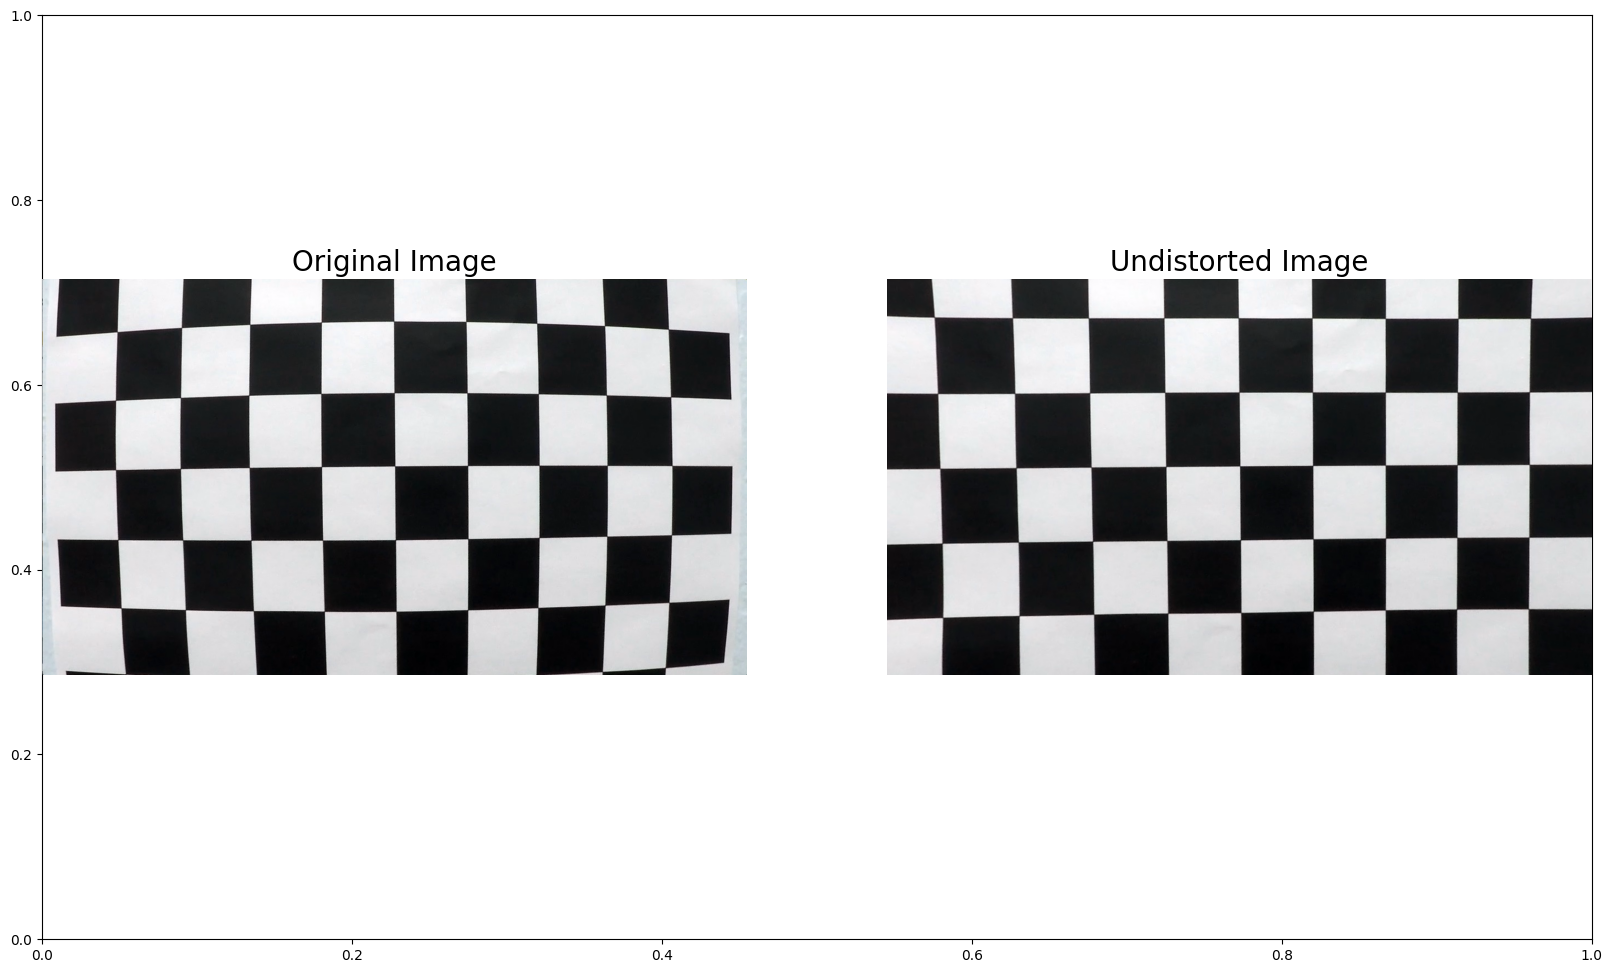

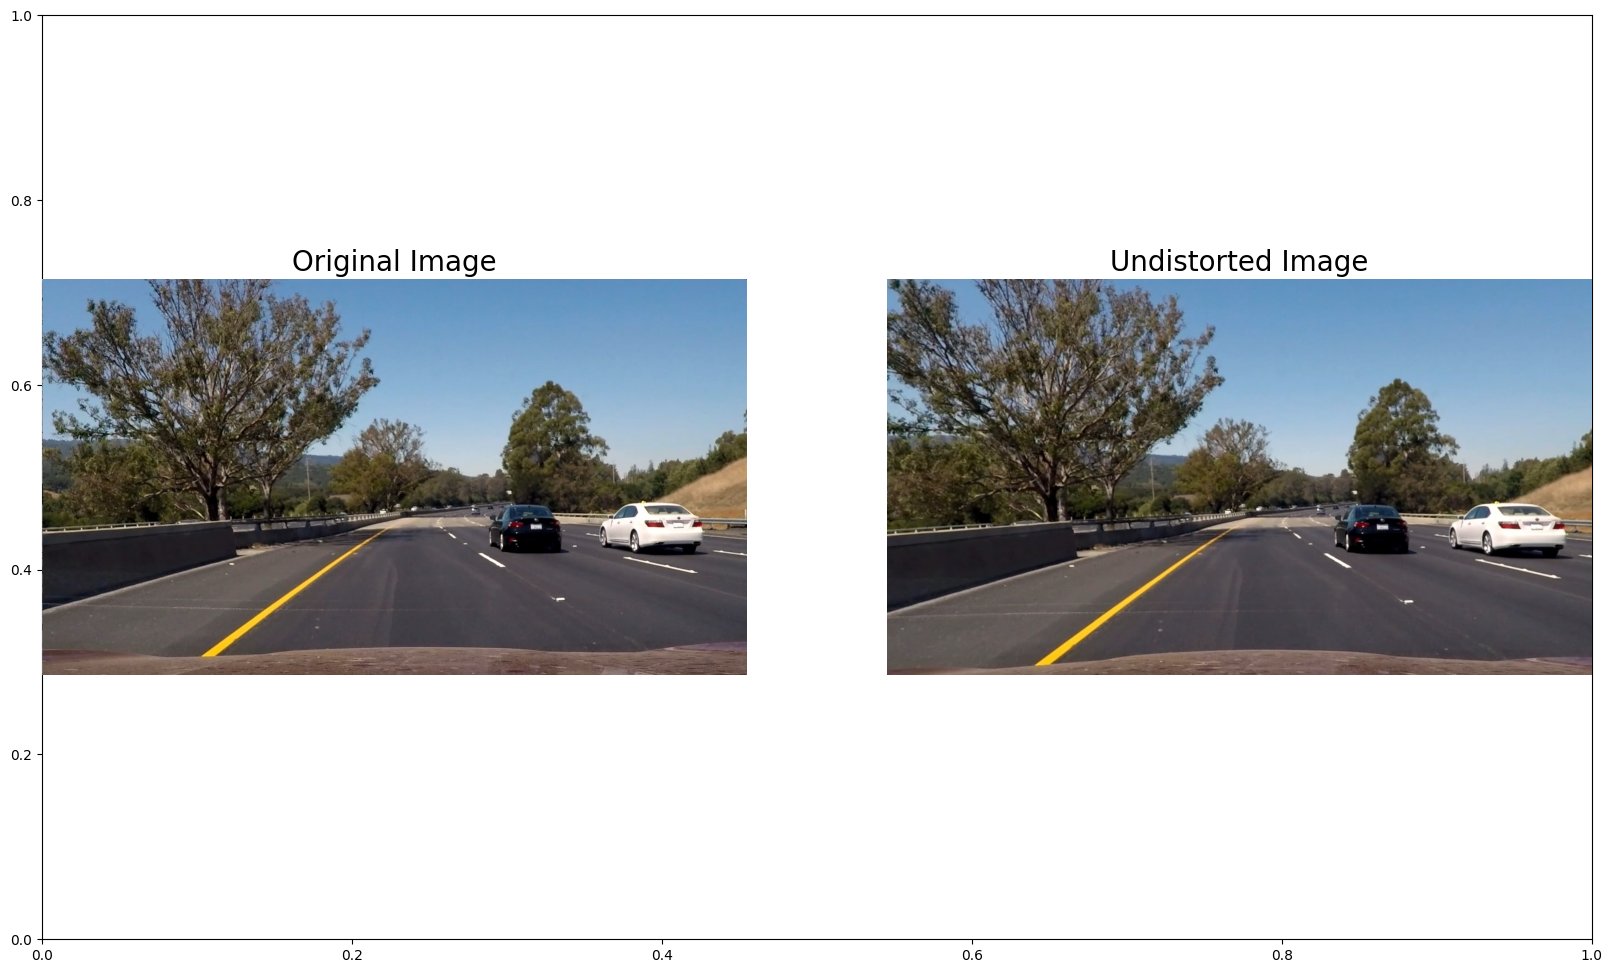

In [4]:
# 1.1 Demonstration of camera calibration and distortion correction
if 1 in plot_demo:
    ccimg = cv2.imread('camera_cal/calibration1.jpg')
    ccimg_undistorted = undistort_images(ccimg, mtx, dist)
    plot_imges([(ccimg, 'Original Image'), (ccimg_undistorted, 'Undistorted Image')], layout='row', cols=2, figsize=(20, 12))
    
    img_orig = mpimg.imread(test_img_paths[5])
    img = undistort_images(img_orig, mtx, dist)
    plot_imges([(img_orig, 'Original Image'), (img, 'Undistorted Image')], layout='row', cols=2, figsize=(20, 12))

### 2. Perspective Transform

In [5]:
### 2. Perspective Transform

from matplotlib.pyplot import plot


IMG_SHAPE = (720, 1280)

def get_roi(img, vertices):
    '''
    Transfroms an image by preseving only the Region of Interest (ROI) represented by the vertices 
    and removes the remainder of the image by setting the pixels intensity to 0. 
    :param img (ndarray): Input image
    :param vertices (ndarray): Vertices representing the region of interest
    :return: Modidied image with only the ROI
    '''
    vertices = np.array(vertices, ndmin=3, dtype=np.int32)
    if len(img.shape) == 3:
        fill_color = (255,) * 3
    else:
        fill_color = 255

    mask = np.zeros_like(img)
    mask = cv2.fillPoly(mask, vertices, fill_color)
    return cv2.bitwise_and(img, mask)

def wrap_image(img,warp_shape, src, dst):
    '''
    Performs perspective transformation on the input image using the provided source and destination points.
    :param img (ndarray): Input image
    :param warp_shape (number, number): Tuple indicating the shape of the warped image
    :param src (ndarray): Source points for perspective transformation
    :param dst (ndarray): Destination points for perspective transformation
    :return: Warped image, Inverse perspective transformation matrix
    '''   
    
    # Get the perspective transform matrix and its inverse
    M = cv2.getPerspectiveTransform(src, dst)
    Minv = cv2.getPerspectiveTransform(dst, src)

    # Warp the image using OpenCV warpPerspective()
    warped = cv2.warpPerspective(img, M, warp_shape, flags=cv2.INTER_LINEAR)

    return warped, M, Minv

def preprocess_image(img, visualize=False):
    '''
    Pre-processes an image: Steps include:
    1. Distortion correction
    2. Perspective transformation
    3. ROI cropping
    Preprocesses the input image by applying a combination of color and gradient thresholds to generate a binary image.
    :param img (ndarray): Input image
    :param visualize (boolean): Whether to visualize the intermediate steps of the preprocessing pipeline
    :return: Binary image resulting from the combination of color and gradient thresholds
    '''
    ysize, xsize = img.shape[0], img.shape[1]

    # 1. Distortion correction
    undistorted = undistort_images(img, mtx, dist)

    # 2. Perspective transformation
    src = np.float32([[585, 460], [203, 720], [1127, 720], [695, 460]])

    dst = np.float32([[320, 0], [320, 720], [960, 720], [960, 0]])
    
    warped, M, Minv = wrap_image(undistorted, (xsize, ysize), src, dst)

    # 3. ROI cropping
    vertices = np.array([[200, ysize],[200, 0], [1100, 0], [1100, ysize]], dtype=np.int32)

    roi = get_roi(warped, vertices)

    # 4. Visualise the transformed image and the region of interest
    if visualize:
        img_copy = np.copy(img)
        roi_copy = np.copy(roi)

        cv2.polylines(img_copy, [src.astype(np.int32)], True, (255, 0, 0), thickness=5)
        cv2.polylines(roi_copy, [dst.astype(np.int32)], True, (255, 0, 0), thickness=5)

        plot_imges([(img_copy, 'Original Image with Source Points'), (roi_copy, 'Bird\'s Eye View Perspective')], layout='row', cols=2, figsize=(20, 12))
    return roi, M, Minv


def get_image(img_path, visualize=False):
    '''
    Reads an image from the provided path and applies the preprocessing pipeline to it.
    :param img_path (string): Path to the input image
    :param visualize (boolean): Whether to visualize the intermediate steps of the preprocessing pipeline
    :return: Preprocessed binary image, Perspective transformation matrix, Inverse perspective transformation matrix
    '''
    img = mpimg.imread(img_path)
    return preprocess_image(img, visualize=visualize)

#### 2.1 Demo

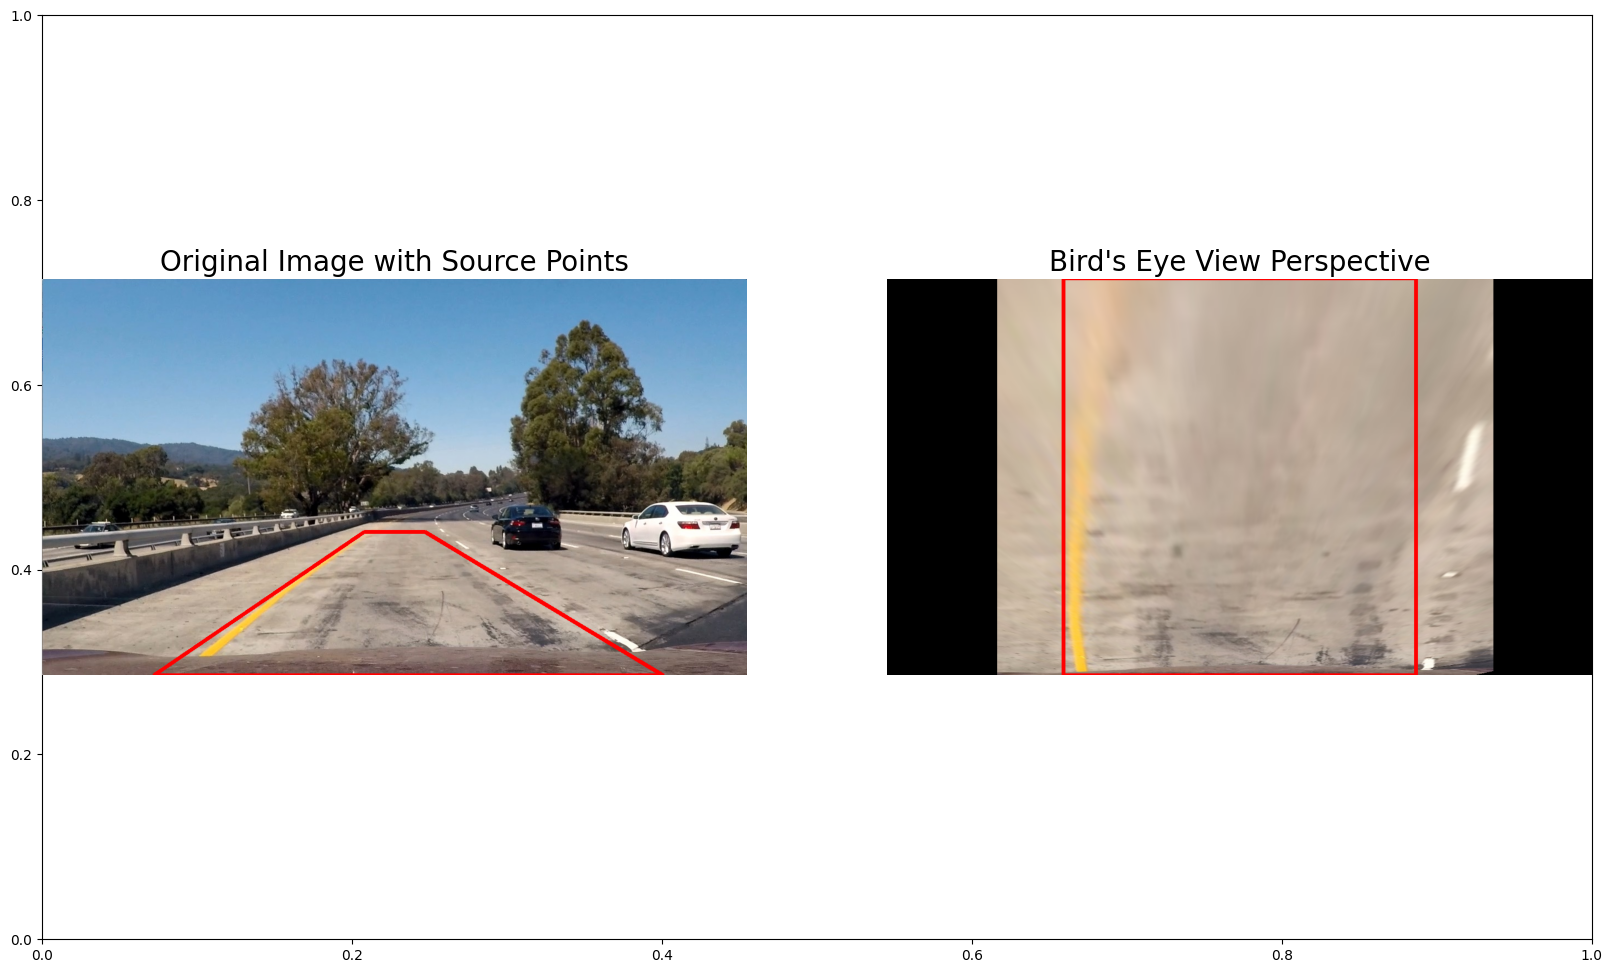

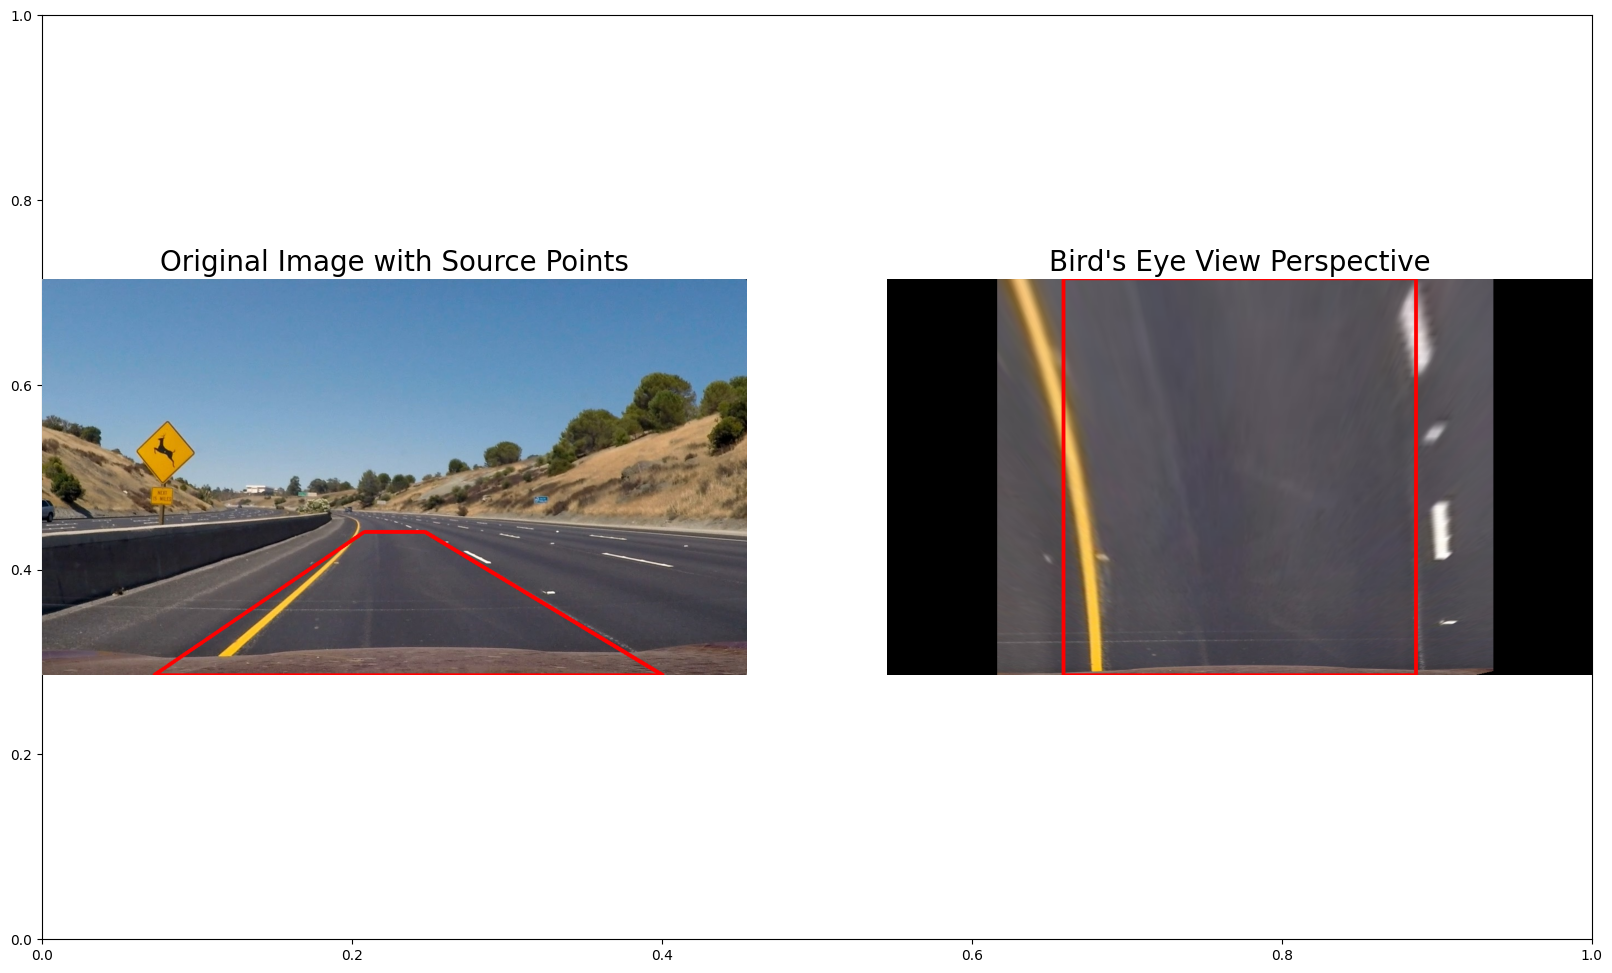

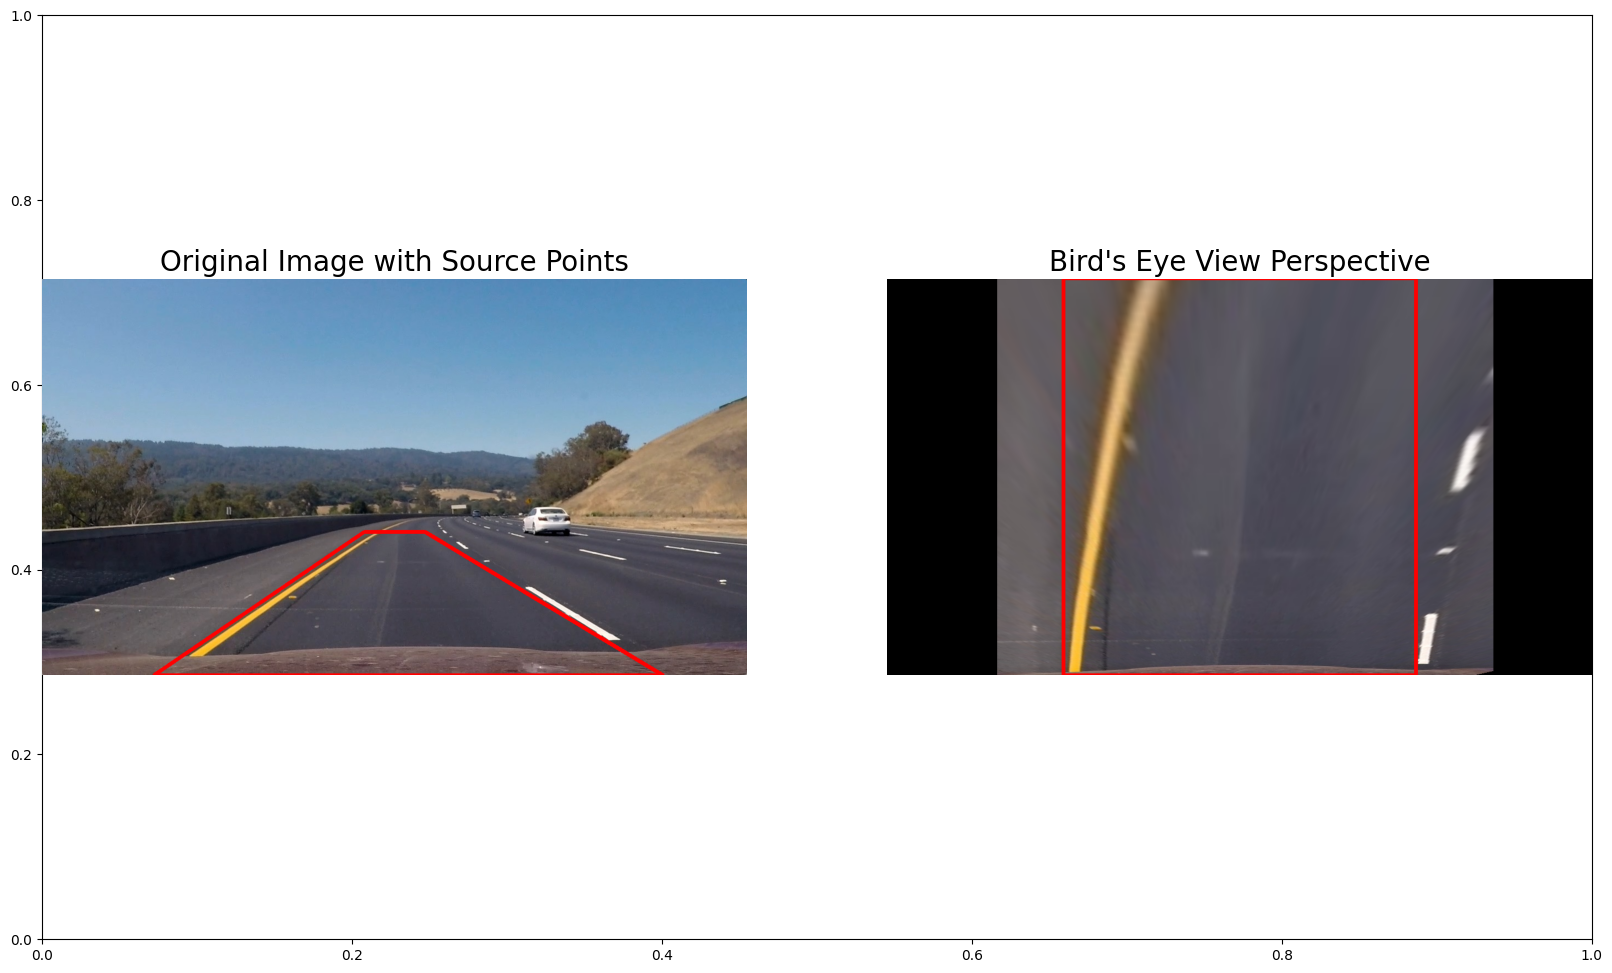

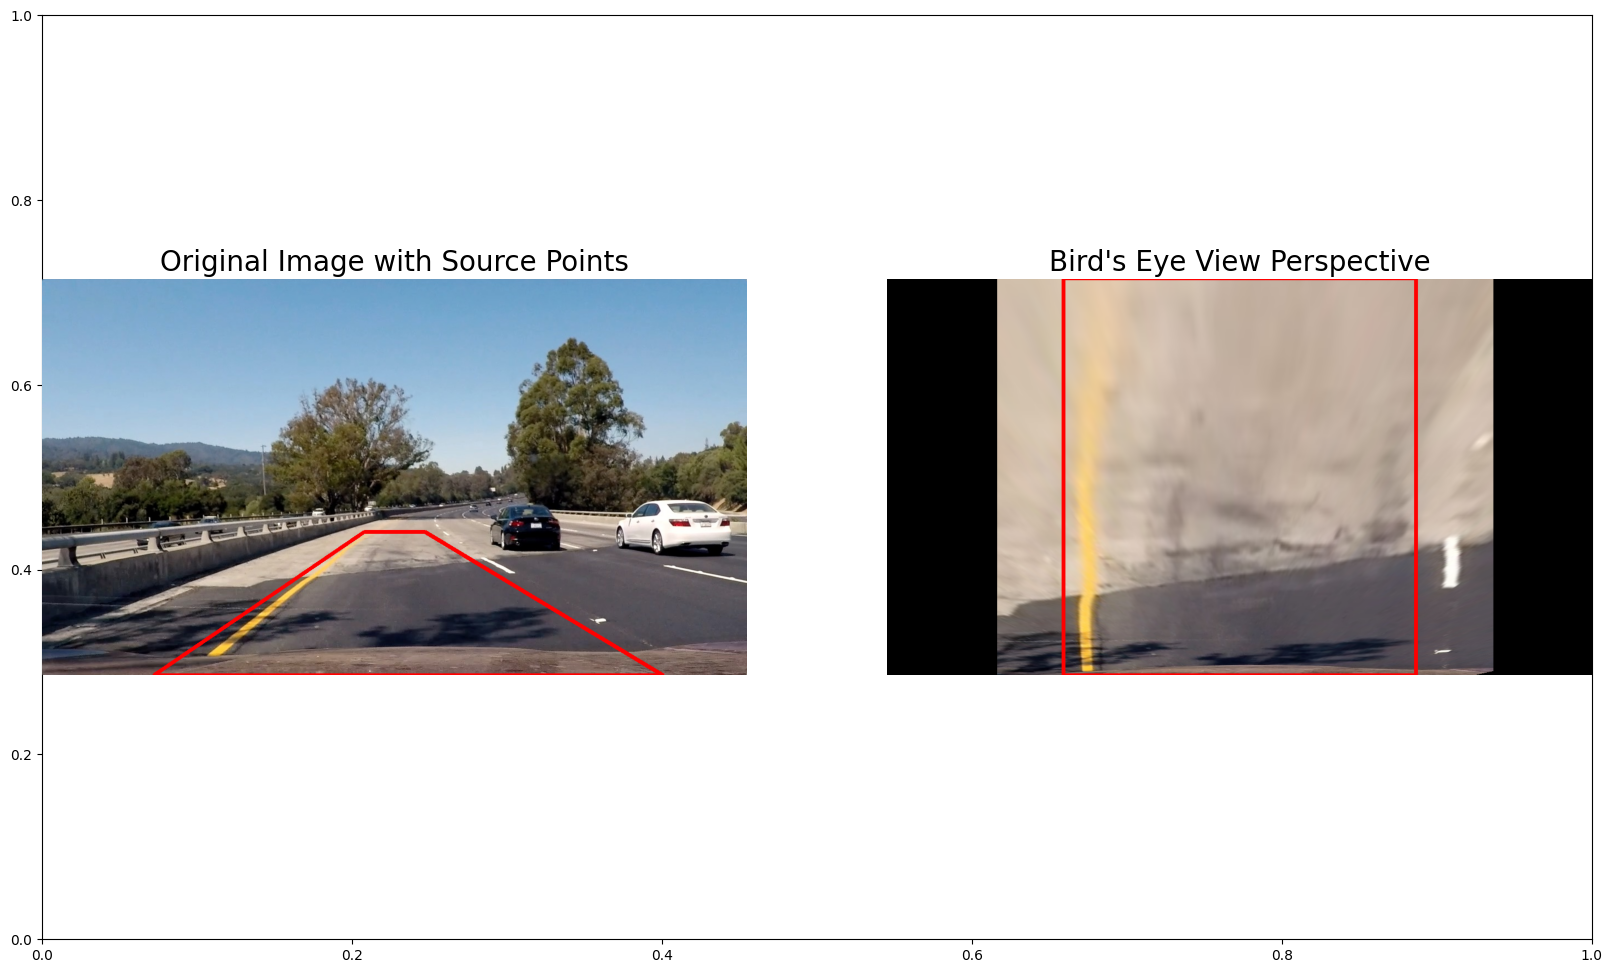

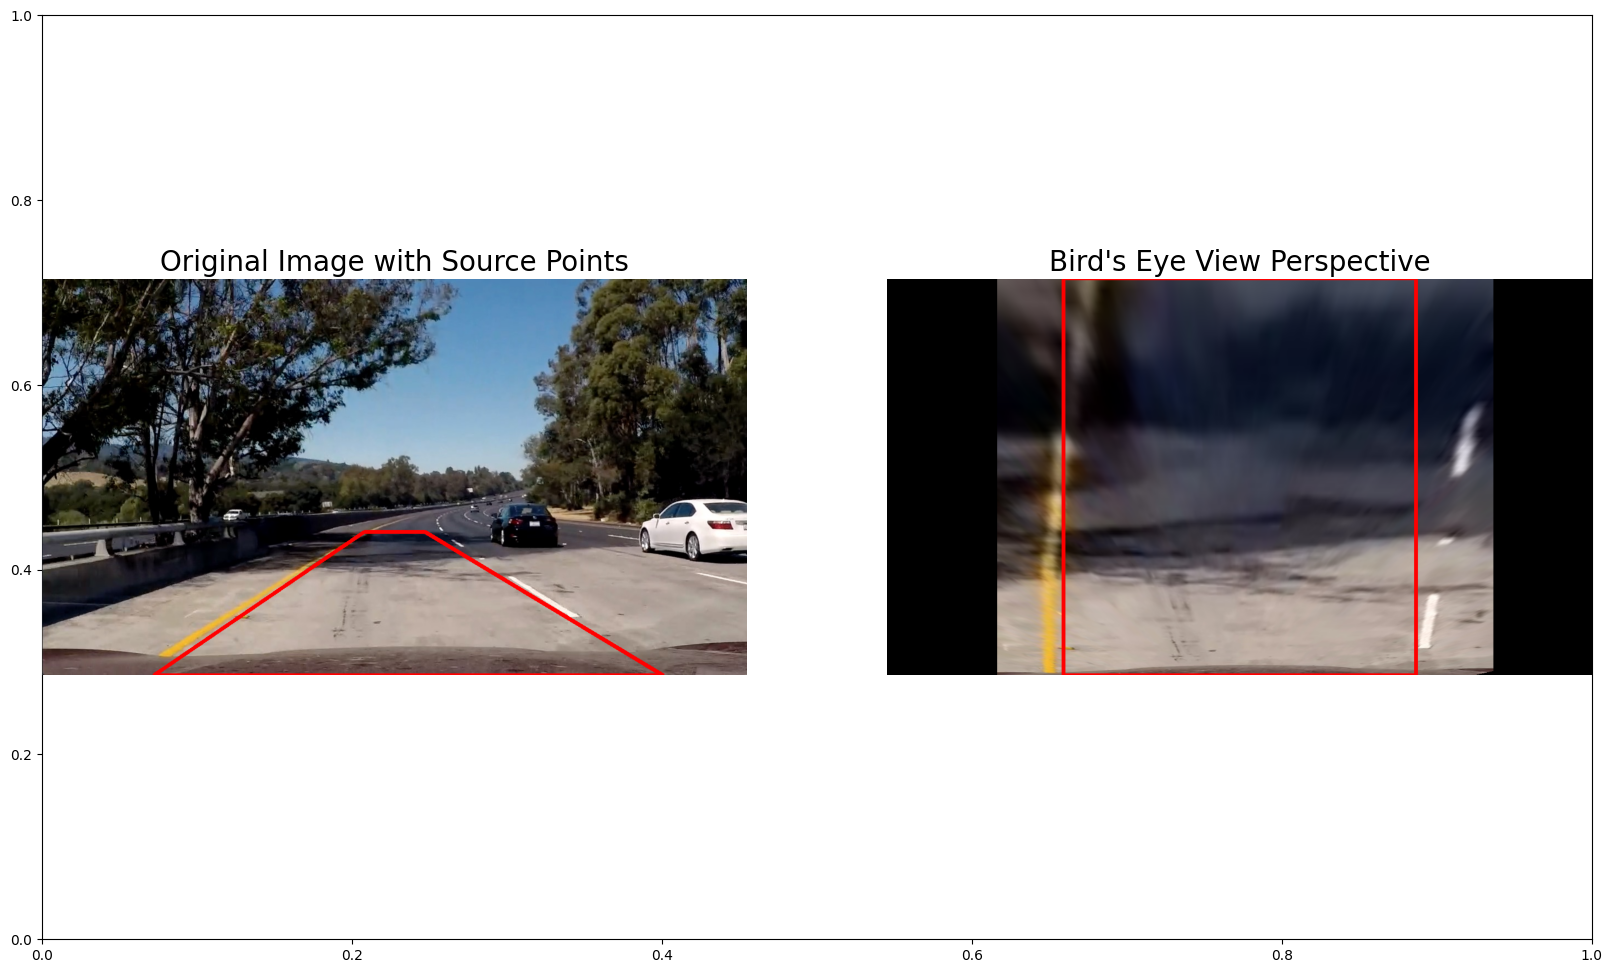

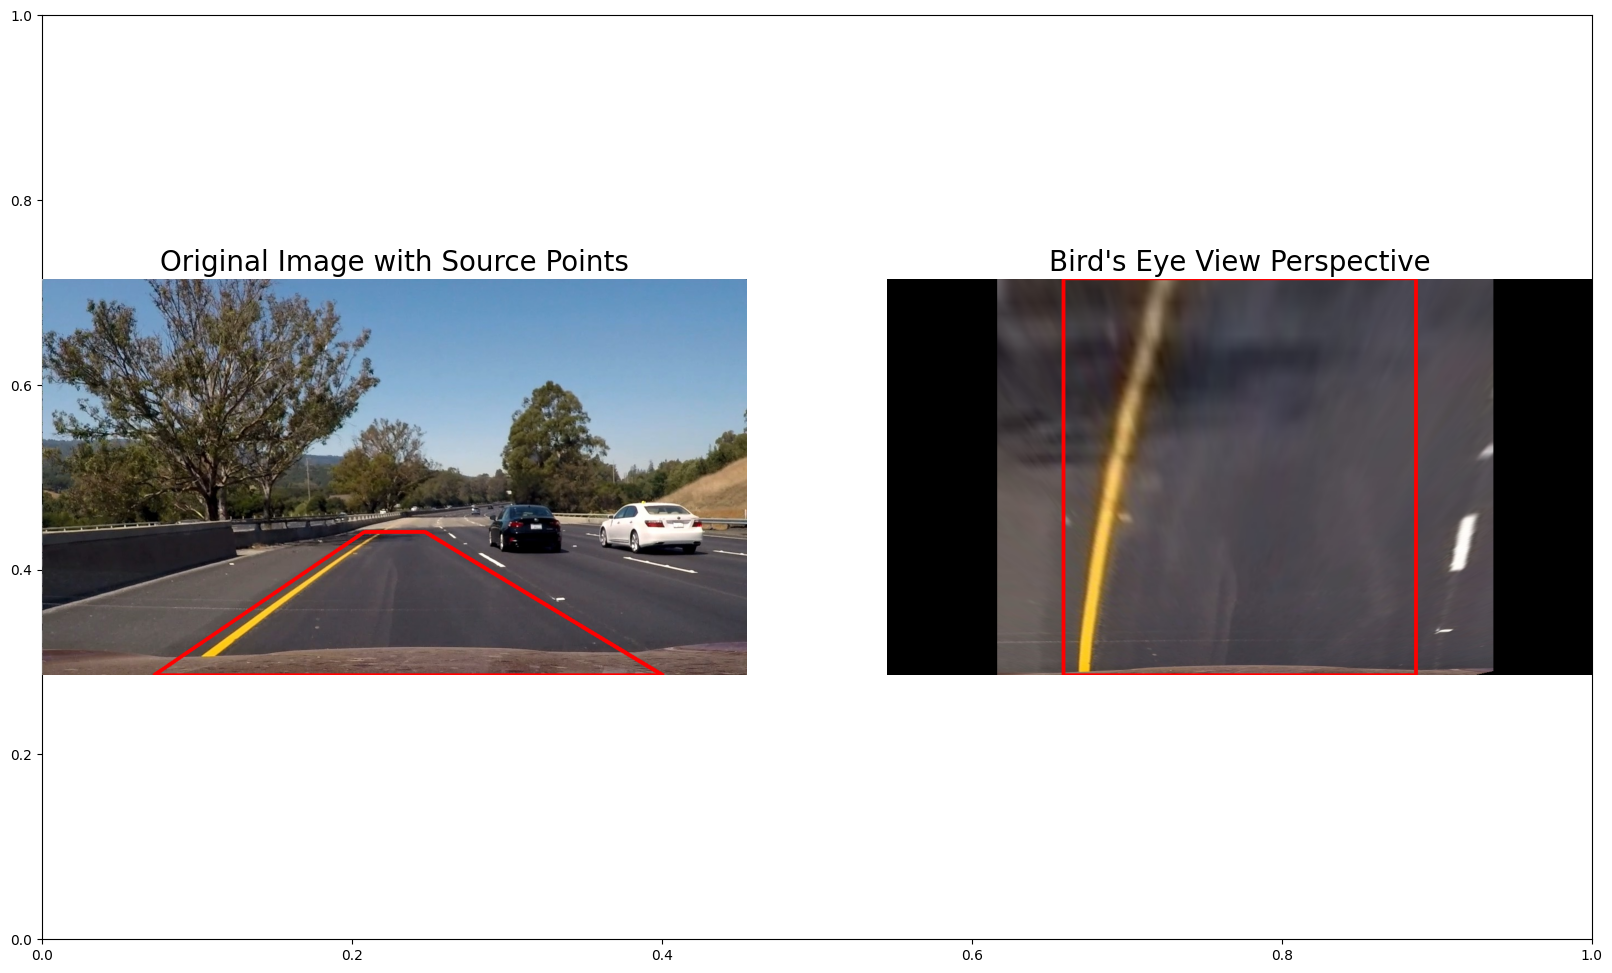

In [14]:
if 2 in plot_demo:
    for img_path in test_img_paths[:]:
        get_image(img_path, visualize=True)

### 3. Generate Thresholded Binary image

In [16]:
### 3. Generate Thresholded Binary Image
def binary_threshold(img, low, high):
    '''
    Applies a binary threshold to the input image using the provided low and high threshold values.
    :param img (ndarray): Input image
    :param low (number): Low threshold value
    :param high (number): High threshold value
    :return: Binary image resulting from applying the binary threshold
    '''
    if len(img.shape) == 2:
        output = np.zeros_like(img)
        mask = (img >= low) & (img <= high)
    elif len(img.shape) == 3:
        output = np.zeros_like(img[:,:,0])
        mask = (img[:,:,0] >= low) & (img[:,:,0] <= high) & (img[:,:,1] >= low) & (img[:,:,1] <= high) & (img[:,:,2] >= low) & (img[:,:,2] <= high)
    output[mask] = 1
    return output

def get_binary_image(img, visualize=False):
    '''
    Generates a binary image by applying a combination of color and gradient thresholds to the input image.
    LAB (Yelow), HSV(Yellow + While), HLS (Yellow + White), RGB (White) and Adpatibe Thresholding ()
    :param img (ndarray): Wrapped image resulting from the perspective transformation and ROI cropping steps of the preprocessing pipeline
    :param visualize (boolean): Whether to visualize the intermediate steps of the binary image generation process
    :return: Binary image resulting from the combination of color and gradient thresholds
    '''
   
    # RGB (White lane)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r_channel = rgb[:,:,0]
    r_binary = binary_threshold(r_channel, 200, 255)

    # HLS (S channel threshold)
    # Convert the image to HLS color space and separate the S channel
    # Lane under shadow
    hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
    s_channel = hls[:,:,2]
    hls_binary = binary_threshold(s_channel, 170, 255)

    # HSV (Yellow + White lane)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    lower_yellow = np.array([15, 100, 100]) 
    upper_yellow = np.array([35, 255, 255])
    yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    yellow_binary = binary_threshold(yellow_mask, 1, 255)
    white_mask = binary_threshold(hsv[:,:,2], 200, 255)
    white_binary = binary_threshold(white_mask, 1, 255)
    hsv_binary = cv2.bitwise_or(yellow_binary, white_binary)

    # LAB ( Yellow detection)
    # Convert the image to LAB color space and separate the Y channel
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel = lab[:,:,0]
    lab_binary = binary_threshold(l_channel, 200, 255)

    # Gradient Threshold (Sobel X) - Edge Lane
    # Apply a Sobel x operator to the grayscale image and take the absolute value of the result
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    abs_sobelx = np.absolute(sobelx)

    # Scale the result to an 8-bit range (0-255) and convert it to type uint8
    scaled_sobel = np.uint8(255*abs_sobelx/np.max(abs_sobelx))

    # Apply a binary threshold to the scaled result of the Sobel x operator
    sx_binary = binary_threshold(scaled_sobel, 20, 100)

    # Adaptive Threshold
    adaptive_binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, -10)
    adaptive_binary = binary_threshold(adaptive_binary, 1, 255)


    # Combine the binary thresholds
    combined = np.asarray(r_binary + hls_binary + hsv_binary + lab_binary + sx_binary + adaptive_binary, dtype=np.uint8)
    combined[combined < 3] = 0
    combined[combined >= 3] = 1

    if visualize:
        plot_imges([(img, 'Original'),(r_binary, 'RGB R Channel Binary'), (hls_binary, 'HLS S Channel Binary'), (hsv_binary, 'HSV Yellow + White Binary'), (lab_binary, 'LAB L Channel Binary'), (sx_binary, 'Sobel X Binary'), (adaptive_binary, 'Adaptive Threshold Binary'), (combined, 'Combined Binary')], layout='row', cols=4, figsize=(20, 12))
    return combined

#### 3.1 Demo

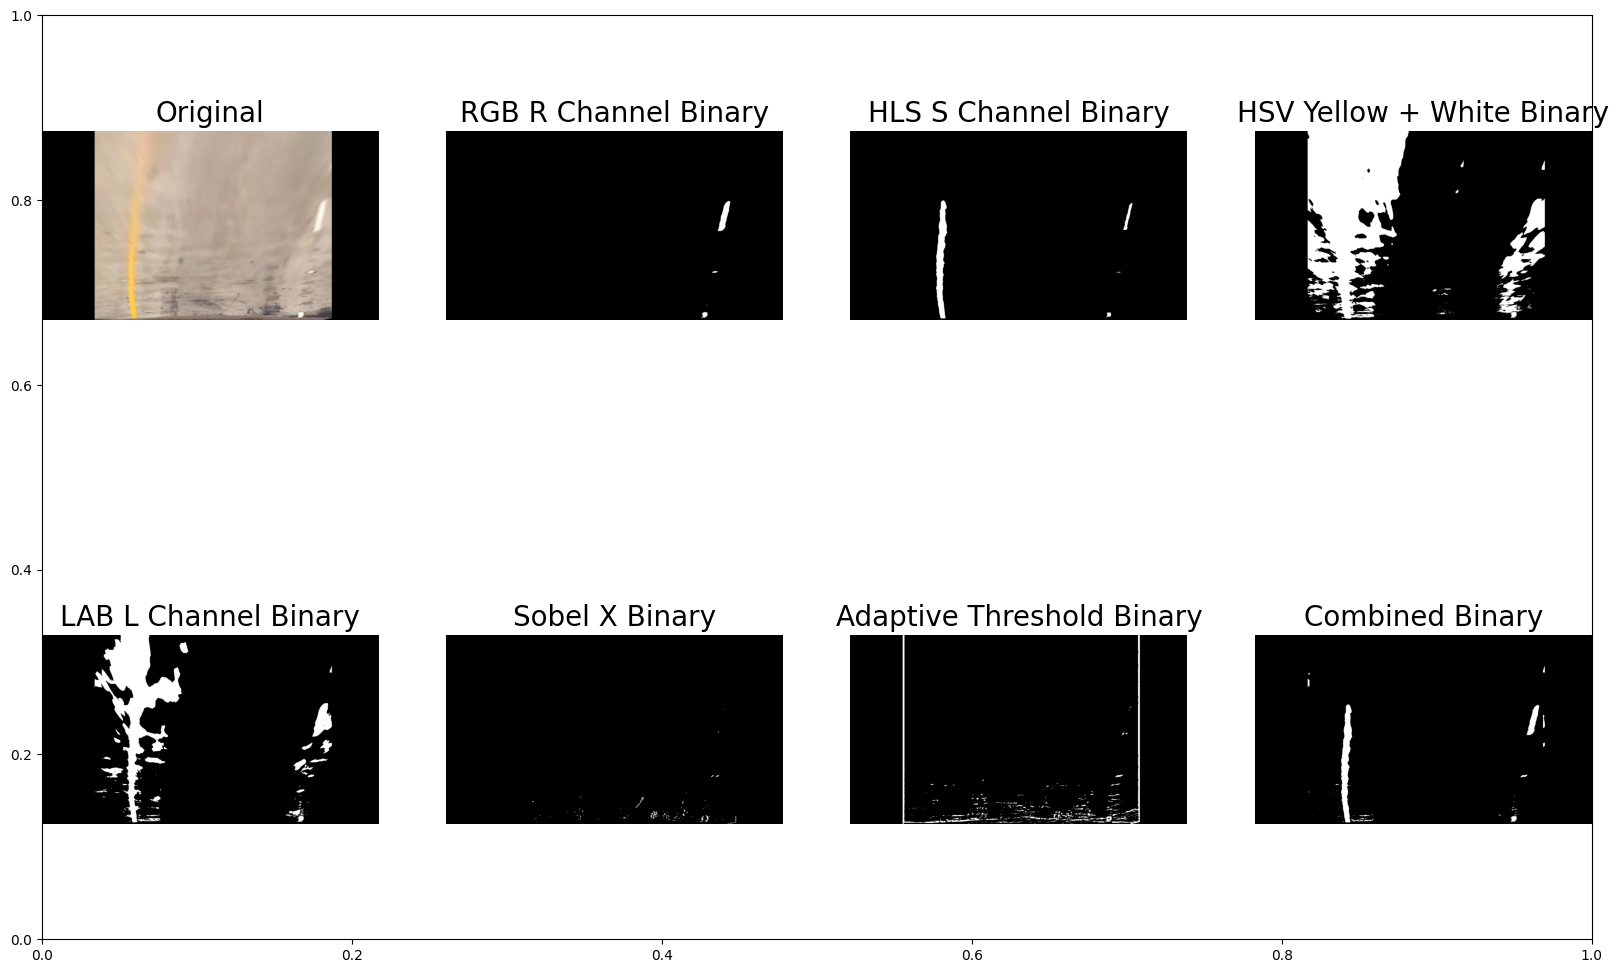

In [17]:
if 3 in plot_demo:
    for img_path in test_img_paths[:1]:
        img, _, _ = get_image(img_path)
       # get_image(img_path, visualize=True)
        get_binary_image(img, visualize=True)

### 4. Detect Lane Lines: Peaks in Histogram and Sliding Window Technique

In [ ]:
def get_poly_points(left_fit, right_fit):
    '''
    Get the points for the left lane and right lane defined by the polynominal coefficients of the fitted lane lines.
    :param left_fit (ndarray): Polynominal coefficients for the left lane line
    :param right_fit (ndarray): Polynominal coefficients for the right lane line
    :return (Tuple(ndarray, ndarray, ndarray, ndarray)): x-y coodinates for the left and right lane lines
    '''
    ysize, xsize = IMG_SHAPE

    # Get the points for the entire height of the image using the polynominal coefficients of the fitted lane lines
     # Generate y values across the image height
    plot_y = np.arange(ysize)
    
    # Compute x values using polynomial
    plot_xleft = left_fit[0]*plot_y**2 + left_fit[1]*plot_y + left_fit[2]
    plot_xright = right_fit[0]*plot_y**2 + right_fit[1]*plot_y + right_fit[2]

    # Keep points inside the image
    left_mask = (plot_xleft >= 0) & (plot_xleft < xsize)
    right_mask = (plot_xright >= 0) & (plot_xright < xsize)
    plot_xleft = plot_xleft[left_mask]
    plot_yleft = plot_y[left_mask]
    plot_xright = plot_xright[right_mask]
    plot_yright = plot_y[right_mask]

    return (
        plot_xleft.astype(int),
        plot_yleft.astype(int),
        plot_xright.astype(int),
        plot_yright.astype(int)
    )
    
def check_validity(left_fit, right_fit, diagnostics=False):
    '''
    Determine the validity of lane lines represented by a set of second order polynomial coefficients
    :param left_fit (ndarray): Polynominal coefficients for the left lane line
    :param right_fit (ndarray): Polynominal coefficients for the right lane line
    :param diagnostics (boolean): Whether to print the diagnostic messages for invalid lane lines
    :return: Whether the lane lines are valid or not
    Lane width hợp lý
    Lane không giao nhau
    Độ cong 2 lane tương tự nhau
    Lane ổn định theo chiều dọc ảnh
    '''
    if left_fit is None or right_fit is None:
        if diagnostics:
            print('Invalid lane lines: One of the lane lines is not detected.')
        return False
    
    plot_xleft, plot_yleft, plot_xright, plot_yright = get_poly_points(left_fit, right_fit)
    
    if len(plot_xleft) == 0 or len(plot_xright) == 0:
        if diagnostics:
            print('Invalid lane lines: No lane line points are detected within the image boundaries.')
        return False
    # Check if the lane lines are parallel by comparing the distance between them at the top and bottom of the image
    distance_top = plot_xright[0] - plot_xleft[0]
    distance_bottom = plot_xright[-1] - plot_xleft[-1]
    if distance_top <= 0 or distance_bottom <= 0:
        if diagnostics:
            print('Invalid lane lines: Lane lines are not parallel.')
        return False
     


????????????????????????????????????


#### 4.1 Demo

In [ ]:
if 4 in plot_demo:
    cache = np.array([])

    for img_path in test_img_paths[:]:
        img, _, _ = get_image(img_path)
        binary_img = get_binary_image(img, visualize=False)

### 5.1 Detect Lane Lines: Adaptive Search

In [ ]:
def polyfit_adapt_search(img, prev_poly_param, visualise=False, diagnostics=False):
    '''
    Function that:
    1. Uses the sliding window technique to perform incremental localised adaptibve threholding over previous detected lane line trajectory to deverlop a thresholded binary image. Then, 
    2. Uses this generated binary image to detect and fit lane lines in a magin around the previous fit rather than performing a blind search.
    Perform an adaptive search for lane lines around the previous lane line polynominal fit.
    :param img (ndarray): Input binary image resulting from the combination of color and gradient thresholds
    :param prev_poly_param (Tuple(ndarray, ndarray)): Previous polynomial coefficients for the left and right lane lines
    :param visualise (boolean): Whether to visualise the search window and detected lane line pixels
    :param diagnostics (boolean): Whether to print diagnostic messages for invalid lane line detection
    :return: Polynomial coefficients for the left and right lane lines detected from the adaptive search, Whether the detected lane lines are valid or not
    '''

    global cache # Cache of the previously detected lane line coefficients to be used when the current detected lane lines are invalid
    global attempts # Number of retries before the pipeline is RESET to dectect lines via the smoothing window technique

    # Santity check
    assert len(img.shape) == 3, 'Input image should be a binary image with a single channel.'

    # Setup
    nb_windows = 10 # Number of sliding windows
    bin_margin = 80 # Width of the windows +/- margin
    margin = 60 # Margin around the previous polynomial to search for lane lines
    window_height = np.int(img.shape[0] / nb_windows) # Height of windows - based on image shape and number of windows
    smoothing_window = 5 # Number of recent frames to consider for smoothing the lane line coefficients
    min_lane_pts = 10 # Minimum number of lane line pixels required for valid lane line detection

    binary = np.zeros_like(img[:,:,0])
    img_plot =np.copy(img)

    left_fit_prev, right_fit_prev = prev_poly_param
    plot_xleft_prev, plot_yleft_prev, plot_xright_prev, plot_yright_prev = get_poly_points(left_fit_prev, right_fit_prev)

    leftx_current = plot_xleft_prev[-1]
    rightx_current = plot_xright_prev[-1]

    # Iterate over the windows, peform localised color thresholding and generate a binary image, and detect lane line pixels within the window
    for window in range(nb_windows):
        # Identify window boundaries in x and y (and right and left)
        win_y_low = IMP_SHAPE[0] - (window + 1) * window_height
        win_y_high = IMP_SHAPE[0] - window * window_height
        win_xleft_low = min(max(0, leftx_current - bin_margin), 1280)
        win_xleft_high = min(max(0, leftx_current + bin_margin), 1280)
        win_xright_low = min(max(0, rightx_current - bin_margin), 1280)
        win_xright_high = min(max(0, rightx_current + bin_margin), 1280)

        img_win_left = img[win_y_low:win_y_high, win_xleft_low:win_xleft_high,:]
        binary[win_y_low:win_y_high, win_xleft_low:win_xleft_high] = \
            get_binary_image(img_win_left, visualize=False)

        img_win_right = img[win_y_low:win_y_high, win_xright_low:win_xright_high,:]
        binary[win_y_low:win_y_high, win_xright_low:win_xright_high] = \
            get_binary_image(img_win_right, visualize=False) 
    
        # Given that we only keep the points/values for a line that lie within the image
        # (see 'get_poly_points' function), the overral length and consequently number of points (i.e. x-values 
        # and y-values) can be < length of the image height. As a result, we check for the presence 
        # of the current window's lower y-value (i.e. win_y_low) as a valid point within the previous detected
        # lane lines to determine the current x-values for the left and right lanes. 
        # If the current window's lower y-value is not present within the previous detected lane line points, 
        # we use the last detected x-values for the left and right lanes as the current x-values for the respective lanes.

        idxs =np.where(plot_yleft_prev == win_y_low)[0]
        if len(idxs) != 0:
            leftx_current = int(plot_xleft_prev[idxs[0]])
        idxs =np.where(plot_yright_prev == win_y_low)[0]
        if len(idxs) != 0:
            rightx_current = int(plot_xright_prev[idxs[0]])
        
        if visualise:
            left_pts = np.array([np.transpose(np.vstack([plot_xleft_prev, plot_yleft_prev]))])
            right_pts = np.array([np.transpose(np.vstack([plot_xright_prev, plot_yright_prev]))])

            # Plot the privious detected lane line
            cv2.polylines(img_plot, np.int32([left_pts]), isClosed=False, color=(255, 20, 147), thickness=4)
            cv2.polylines(img_plot, np.int32([right_pts]), isClosed=False, color=(255, 20, 147), thickness=4)

            # Blend the localised image window with its corresponding thresholded binary version
            bin_win_left = binary[win_y_low:win_y_high, win_xleft_low:win_xleft_high]
            bin_win_left = np.dstack(bin_win_left, np.zeros_like(bin_win_left), np.zeros_like(bin_win_left))*255
            blended_left = cv2.addWeighted(img_win_left, 0.5, bin_win_left, 0.7, 0)

            bin_win_right = binary[win_y_low:win_y_high, win_xright_low:win_xright_high]
            bin_win_right = np.dstack(bin_win_right, np.zeros_like(bin_win_right), np.zeros_like(bin_win_right))*255
            blended_right = cv2.addWeighted(img_win_right, 0.5, bin_win_right, 0.7, 0)

            # Draw the binary search windows
            cv2.rectangle(img_plot, (win_xleft_low, win_y_low), (win_xleft_high, win_y_high), (0,255,0), 2)
            cv2.rectangle(img_plot, (win_xright_low, win_y_low), (win_xright_high, win_y_high), (0,255,0), 2)

            f, _ = plt.subplots(1, 2, figsize=(13, 5))
            plt.subplot(1, 2, 1)
            plt.axis('off')
            plt.imshow(binary, cmap='gray')

            plt.subplot(1, 2, 2)
            plt.axis('off')
            plt.imshow(img_plot)
            
            plt.subplots_adjust(top=0.98, bottom=0.02, left=0.0, right=1.0, hspace=0.1, wspace=0.05)
            plt.savefig('./gif_images/window1{:2}.png'.format(window))

            # The blended Binary windows and Image window is added latrer for better visualisation of the search process in the generated GIF (see cell 7)
            img_plot[win_y_low:win_y_high, win_xleft_low:win_xleft_high,:] = blended_left
            img_plot[win_y_low:win_y_high, win_xright_low:win_xright_high,:] = blended_right

        # Identify the x and y positions of all nonzero pixels in the image
        nonzero = binary.nonzero()
        nonzeroy = np.array(nonzero[0])
        nonzerox = np.array(nonzero[1])

        # Extract all the 
        left_lane_inds = \
            ((nonzerox > (left_fit_prev[0]*(nonzeroy**2) + left_fit_prev[1]*nonzeroy + left_fit_prev[2] - margin)) & \
            (nonzerox < (left_fit_prev[0]*(nonzeroy**2) + left_fit_prev[1]*nonzeroy + left_fit_prev[2] + margin)))
        
        right_lane_inds = \
            ((nonzerox > (right_fit_prev[0]*(nonzeroy**2) + right_fit_prev[1]*nonzeroy + right_fit_prev[2] - margin)) & \
            (nonzerox < (right_fit_prev[0]*(nonzeroy**2) + right_fit_prev[1]*nonzeroy + right_fit_prev[2] + margin)))
        leftx = nonzerox[left_lane_inds]
        lefty = nonzeroy[left_lane_inds]
        rightx = nonzerox[right_lane_inds]
        righty = nonzeroy[right_lane_inds]

        # Sanity checks
        if len(leftx) > min_lane_pts:
            left_fit_prev = np.polyfit(lefty, leftx, 2) 
        else:
            if diagnostics: print ('WARNING: Less than {} pts detected for the left lane. {}'.format(min_lane_pts, len(leftx)))

        if len(rightx) > min_lane_pts:
            right_fit_prev = np.polyfit(righty, rightx, 2)
        else:
            if diagnostics: print ('WARNING: Less than {} pts detected for the right lane. {}'.format(min_lane_pts, len(rightx)))

        valid = check_validity(left_fit_prev, right_fit_prev, diagnostics=diagnostics)

        # Perfrom smoothing via moving average
        if valid:
            if len(cache) < smoothing_window
                cache = np.append(cache, [[left_fit_prev, right_fit_prev]], axis=0)
            elif len(cache) >= smoothing_window:
                cache[:1] = cache[1:]
                cache[-1:] = [[left_fit_prev, right_fit_prev]]
            
            avg_param = np.mean(cache, axis=0)
            left_fit_prev = avg_param[0]
            right_fit_prev = avg_param[1]
            plot_xleft_prev, plot_yleft_prev, plot_xright_prev, plot_yright_prev = get_poly_points(left_fit_prev, right_fit_prev)
            curr_poly_param = (left_fit_prev, right_fit_prev)
        else:
            attempts += 1
            curr_poly_param = prev_poly_param

        out = np.dstack((binary, binary, binary))*255
        win_img = np.zeros_like(out)

        # Color the detected lane line pixels
        out[lefty,leftx] = [255, 0, 0]
        out[righty,rightx] = [255, 10, 255]

        left_window1 = np.array([np.transpose([plot_xleft_prev - margin, plot_yleft_prev])])
        left_window2 = np.array([np.flipud(np.transpose([plot_xleft_prev + margin, plot_yleft_prev]))])
        left_pts = np.hstack((left_window1, left_window2))

        right_window1 = np.array([np.transpose([plot_xright_prev - margin, plot_yright_prev])])
        right_window2 = np.array([np.flipud(np.transpose([plot_xright_prev + margin, plot_yright_prev]))])
        right_pts = np.hstack((right_window1, right_window2))

        # Draw the search boundaries around the detected lane lines
        cv2.fillPoly(win_img, np.int_([left_pts]), (0,255, 0))
        cv2.fillPoly(win_img, np.int_([right_pts]), (0,255, 0))

        out = cv2.addWeighted(out, 1, win_img, 0.25, 0)

        left_poly_pts = np.array([np.transpose(np.vstack([plot_xleft_prev, plot_yleft_prev]))])
        right_poly_pts = np.array([np.transpose(np.vstack([plot_xright_prev, plot_yright_prev]))])

        # Draw the fitted lane lines
        cv2.polylines(out, np.int32([left_poly_pts]), isClosed=False, color=(200, 255, 155), thickness=4)
        cv2.polylines(out, np.int32([right_poly_pts]), isClosed=False, color=(200, 255, 155), thickness=4)

        return out, curr_poly_param


#### 5.1 Demo

In [ ]:
if 5 in plot_demo:
    cache = np.array([]) # Cache for smoothing the lane line coefficients
    attempts = 0 # Number of retries before resetting to perform a blind search via the sliding window technique
    max_attempts = 4 # Maximum number of retries before resetting to perform a blind search via the sliding window technique

    for frame_path in video2[0: 5]:
        img = mpimg.imread(frame_path)
        warped, (M, Minv) = get_image(frame_path)

        if reset == True:
            birary = get_binary_image(warped)
            ret, out, poly_param = polyfit_sliding_window(birary, visualise=False, diagnostics=True)
            if ret:
                reset = False
                cache = np.append(cache, [poly_param], axis=0)
        else:
            out, poly_param = polyfit_adapt_search(warped, poly_param, visualise=False, diagnostics=True)
            if attempts == max_attempts:
                reset = True
                attempts = 0
            
            out_unwarped = cv2.warpPerspective(out, Minv, (IMG_SHAPE[1], IMG_SHAPE[0], flags=cv2.INTER_LINEAR))

            img_overlay = np.copy(img)
            img_overlay = cv2.addWeighted(out_unwarped, 0.5, img, 0.5, 0)

            plot_imges([(warped, 'Orginal'), (out, 'Out'), (img_overlay, 'Overlay')], figsize=(20, 18))

### 6. Compute meters/ pixel

In [ ]:
def compute_mppx(img, dashed_line_loc, visualise=False):
    '''
    Converts from pixel space to real wold space and calculates the meters/pixel
    :param img (ndarry): Warped Image
    :param dashed_line_loc (String): Dashed line location (left/right)
    :param visualise (boolean): Boonlean flag for visualisation
    :return (float32, float32): (meters/pixel y direction, meters/pixel x-direction)
    '''
    lane_width = 3.7
    dashed_line_len = 3.048

    if dashed_line_loc == 'left':
        y_top = 295
        t_bottom = 405
    elif dashed_line_loc == 'right':
        y_top = 395
        y_bottom = 495

    binary = get_binary_image(img)
    histogram = np.sum(binary[binary.shape[0] // 2:, :], axis=0)
    midpoint = int(histogram.shape[0] // 2)
    x_left = np.argmax(histogram[:midpoint])
    x_right = np.argmax(histogram[midpoint:]) + midpoint

    y_mppx = lane_width / (x_right - x_left)
    x_mppx = dashed_line_len / (y_bottom - y_top)

    if visualise:
        plt.figure(figsize=(10,8))
        plt.imshow(img)
        plt.axis('off')

        if dashed_line_loc == 'left':
            plt.plot((x_left, x_left), (y_top, y_bottom), 'r')
            plt.text(x_left + 10, (y_top + y_bottom) // 2, '{} m'.format(dashed_line_len), color='r', fontsize=20)
        elif dashed_line_loc == 'right':
            plt.plot((x_right, x_right), (y_top, y_bottom), 'r')
            plt.text(x_right + 10, (y_top + y_bottom) // 2, '{} m'.format(dashed_line_len), color='r', fontsize=20)

        plt.plot((x_left, x_right), (img.shape[0] - 200, img.shape[0] - 200), 'r')
        plt.text((x_left + x_right) // 2, img.shape[0] - 200, '{} m'.format(lane_width), color='r', fontsize=20)
    return y_mppx, x_mppx

#### 6.1 Demo

In [ ]:
if 6 in plot_demo:
    visualise = True
else:
    visualise = False

img, _ = get_image(test_img_paths[0])
y_mppx1, x_mppx1 = compute_mppx(img, dashed_line_loc='right', visualise=visualise)

img, _ = get_image(test_img_paths[1])
y_mppx2, x_mppx2 = compute_mppx(img, dashed_line_loc='left', visualise=visualise)

x_mppx = (x_mppx1 + x_mppx2) / 2
y_mppx = (y_mppx1 + y_mppx2) / 2

print('Average meter/px along a-axis" {:.4f}'.format(x_mppx))
print('Average meter/px along y-axis" {:.4f}'.format(y_mppx))

### 7. Compute Lane Line Curvature

In [ ]:
def compute_offset_from_center(poly_param,x_mppx):
    ''' 
    Compute the offset of the car from the center of the detected Lane lines
    :param poly_param (ndarray): Set of 2nd order polynomial coefficients that
    represent the detected lane lines
    :param x_mppx (float32): meters/pixel in the x-direction
    :return (float32): Offset
    '''
    plot_xleft, plot_yleft, plot_xright, plot_right = get_poly_points(poly_param[0], poly_param[1])
    
    lane_center = (plot_xright[-1] + plot_xleft[-1]) / 2
    car_center = IMG_SHAPE[1] / 2

    offset = (lane_center - car_center) * x_mppx
    return offset

def compute_curvature(poly_param, y_mppx, x_mppx):
    ''' Computes the curvature of the lane line (in meters)
    :param poly_param (ndarray): set of 2nd order coefficients that represent the detected lane lines
    :param y_mppx (float32): metres/pixel in y-direction
    :param x_mppx (float32): metres/pixel in x-direction
    :return (float32): Curvature (in metres)
    '''
    plot_xleft, plot_yleft, plot_xright, plot_right = get_poly_points(poly_param[0], poly_param[1])

    y_eval = np.max(plot_yleft)
    left_fit_cr = np.polyfit(plot_yleft + y_mppx, )


